### See the related Mathematica notebook "Dephasing.nb" for the derivations of expressions used here

In [36]:
import numpy as np
import matplotlib.pyplot as pl
import time
from joblib import Parallel, delayed

In [37]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

In [38]:
def strobo(beta, data, f_ratio):
    new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta
    f_new = f_signal/f_ratio
    
    new_t *= f_new #changes the frequency to the new downsampled frequency (approximately, not exactly)
    floor_t = np.floor(new_t) #For some reason floor works better than round. Take it to the nearest time index which are integers
    idx = np.nonzero(np.diff(floor_t)) #The step that downsamples
    resampled = data[idx]
    t_out = (new_t[idx])/f_new
    return (resampled, t_out)

Specific arguments

In [39]:
f0 = 120
Mc = 3e-4* 2e30
f_max = 200
T_obs = 1e4
pad_len = int(340*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)

f_signal = 5*f_max
nt = round(f_signal*T_obs)
t = np.arange(nt)/f_signal
f_ratio = 25

In [40]:
beta

2.7439303219997145e-07

## Without any error

First we check we understand everything when beta is known exactly. 
We generate the phase, resample and check it's monochromatic

In [41]:
phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta

In [42]:
temp_out, temp_time = strobo(beta, phi, 25)

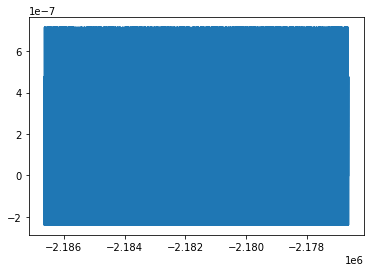

In [43]:
monochromatic = 2*pi*f0*(temp_time - temp_time[0]) + temp_out[0]
pl.plot(temp_time, monochromatic - temp_out)

In [44]:
np.allclose(monochromatic, temp_out)

True

This demonstrates resampling works as expected. After resampling, identical to monochromactic up to numerical error

## Exact dephasing

In [45]:
delta_beta = 1e-5 * beta
phi_exact = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
phi_offset = -6*pi/5*f0*(1-8./3.*(beta+delta_beta)*t)**(5/8)/(beta+delta_beta)

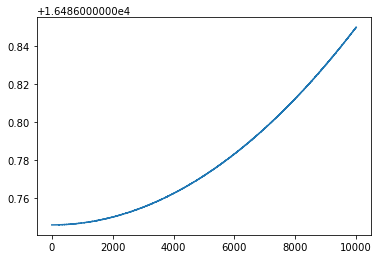

In [46]:
num_dephasing = phi_offset - phi_exact
pl.plot(t, num_dephasing)
#Includes a constant offset because of the phi0 difference

We see that the there is a dephasing that scales with time. Note that at t=0 the dephasing != 0 because we expand are $\Delta \beta$, not around $t$

In [47]:
# We analytically can compute what the dephasing at t=0 is
const = 6*pi*f0*delta_beta/(5*(beta**2+delta_beta*beta))
np.isclose(num_dephasing[0], const)

True

## Resampled dephasing

In [48]:
temp_out, temp_time = strobo(beta, phi_offset, 25)
monochromatic = 2*pi*f0*(temp_time - temp_time[0]) + temp_out[0]
resampled_dephasing = temp_out - monochromatic

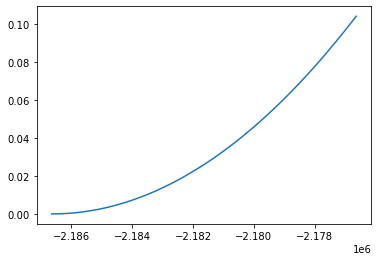

In [49]:
pl.plot(temp_time, resampled_dephasing)

We check it is the same as the numerical dephasing (which it should be)

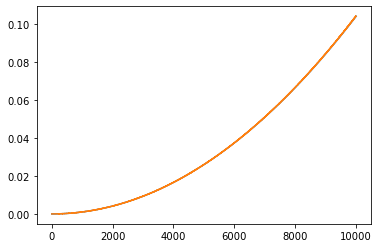

In [51]:
pl.plot(temp_time - temp_time[0], resampled_dephasing)
pl.plot(t, num_dephasing-const)

Cannot check all close because dimensions not the same. Should interpolate and check allclose but SplineInterpolation acted weirdly. By eye looks identical

## Approximate dephasing

We want to find an approximation for the dephasing since the full analytical form is hard to work with

In [60]:
def approx_dephasing(t, f0, beta, delta_beta):
    temp0 = 6*f0*pi*(-1+beta*t)*delta_beta
    temp1 = 5*beta**2*(1-8/3*beta*t)**(3/8)
    return -temp0/temp1

In [61]:
approx_dephasing = approx_dephasing(t, f0, beta, delta_beta)

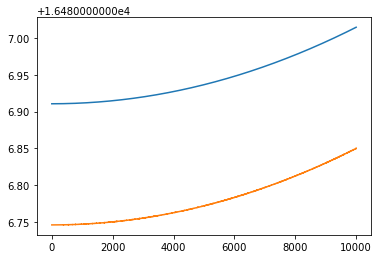

In [67]:
pl.plot(t, approx_dephasing)
pl.plot(t, num_dephasing)

Curve looks of the correct form but the $t=0$ term is slightly different, intuitively this is because the expansion around $\Delta \beta$ has a $\Delta \beta / \beta$ piece of the expansion around $t=0$. Here the constant is $\frac{6 \pi f_0 \Delta \beta}{5\beta^2}$

In [68]:
const = 6*pi*f0*delta_beta/(5*beta**2)

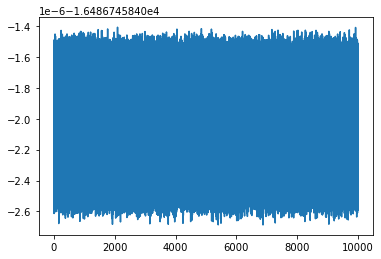

In [69]:
pl.plot(t, approx_dephasing - num_dephasing - const)

In [70]:
np.allclose(approx_dephasing-const*delta_beta/beta, num_dephasing )

True

## With tau - resampled time

We check the analytics also work with $\tau$ the resampled time, this in principle should be exactly identical

In [71]:
# These are just the same expressions written in different ways

def g(tau, beta, delta_beta):
    A = 3**(8/5)*5**(-3/5)
    B = 3
    C = 8
    return delta_beta/beta * (A+B*(beta*tau)**(8/5))/(C*(beta*tau)**(8/5))

def tau_dephasing(tau, beta, delta_beta):
    temp0 = 3*f0*pi*delta_beta*(3**(3/5)*5**(2/5)+5*np.power(beta*tau, 8/5))
    temp1 = 20*beta**2*np.power(beta*tau, 3/5)
    return temp0/temp1
# Be careful with numerical overflow, changing the position of
# delta_beta caused big problems 

In [72]:
tau = 3/5*(1-8/3*beta*t)**(5/8)/beta

In [73]:
# pi/4 is normal phase error condition

In [74]:
# First we check all the phase without any error is correct
np.allclose(-2*pi*f0*tau, phi_exact) 

True

In [75]:
tau_dephasing = tau_dephasing(tau, beta, delta_beta)
resampled_dephasing = 2*pi*f0*tau*g(tau, beta, delta_beta)

In [76]:
np.allclose(tau_dephasing, resampled_dephasing)
# The two expressions are the same as expected

True

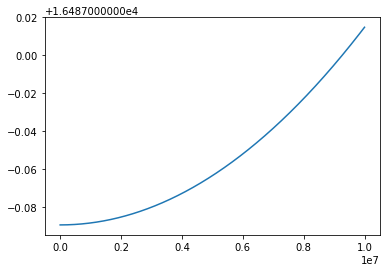

In [77]:
pl.plot(tau_dephasing)

In [78]:
np.allclose(tau_dephasing, approx_dephasing)
# And it is also the same as approx_dephasing, 
# so we understand everything

True

Now we have an understanding of an analytical approximation for the phase error caused by resampling with some error $\Delta \beta$. As long as the phase error is less than $\approx \pi/4$, the power should be mostly confined into 1 bin